# Fair-Seldonian on real data: UCI Adult income

This notebook applies the Quasi-Seldonian Algorithm (QSA) to the UCI Adult
income dataset under a **demographic-parity** constraint, and shows both sides of
the Seldonian guarantee on real data:

* an ordinary logistic regression reaches good accuracy but predicts the positive
  class at very different rates for the two groups (a demographic-parity gap), and
* QSA, asked to certify that gap is bounded, returns **No Solution Found**
  rather than shipping the biased model.

**Task framing**

| symbol | meaning |
|--------|---------|
| `Y` (label) | income > 50K |
| `T` (sensitive) | sex (1 = Male, 0 = Female) |
| `X` (features) | standardized numeric columns, with `T` appended as the final column (library convention) |

> Requires network access on the first run to download the dataset (cached afterwards).

## Background: what is demographic parity?

**Demographic parity** (also called *statistical parity* or the *independence*
criterion) asks that a model's prediction be statistically independent of the
sensitive attribute. For a binary classifier with prediction $\hat{Y}$ and
sensitive group $A$:

$$P(\hat{Y} = 1 \mid A = a) = P(\hat{Y} = 1 \mid A = b) \quad \text{for all groups } a, b.$$

In words: every group is predicted positive at the same rate, **regardless of the
true label** $Y$. In practice we bound the gap by a tolerance $\epsilon$:

$$\left| P(\hat{Y}=1 \mid A=1) - P(\hat{Y}=1 \mid A=0) \right| \le \epsilon,$$

which is exactly what we enforce below with $\epsilon = 0.10$. A closely related
industry rule of thumb is the *disparate-impact* "four-fifths (80%) rule", which
compares the **ratio** of group positive rates rather than their difference
(Feldman et al., 2015).

**How it differs from equalized opportunity.** Because demographic parity ignores
$Y$, it can be met by a model that is deliberately inaccurate for one group. Label-conditioned criteria such as *equalized odds* and *equalized opportunity*
(Hardt et al., 2016) instead require error rates to match across groups. There is
no single "correct" fairness metric: the appropriate choice is context-dependent,
and several criteria are provably incompatible except in degenerate cases (Barocas,
Hardt & Narayanan, 2023; Dwork et al., 2012).

**Why demographic parity for this task?** Predicting `income > 50K` stands in here
for an *allocative* decision - one where a positive prediction grants access to a
benefit (a loan, an interview, a targeted offer). When the goal is equal access
across groups, demographic parity is a natural target: it constrains the *rate at
which the benefit is allocated* to each group. This is especially appropriate for
Adult, where the labels themselves reflect historical disparities (men are labelled
high-income far more often), so a label-conditioned criterion would bake that
societal gap in as ground truth. If instead you trusted the labels and only wanted
equal accuracy among the truly-qualified, equalized opportunity would fit better
(see [`custom_constraint.py`](custom_constraint.py)).

**In this library**, the confusion-matrix cells `TP`, `FP`, `TN`, `FN` are reported
as fractions of each group (they sum to 1 within a group), so the predicted-positive
rate is `TP + FP`. That is why demographic parity is written as the postfix
constraint `TP(1) FP(1) + TP(0) FP(0) + - abs 0.1 -`.

In [2]:
import numpy as np
from sklearn.datasets import fetch_openml

from fair_seldonian.algorithms import QSA
from fair_seldonian.config import SeldonianConfig
from fair_seldonian.models import predict, simple_logistic

## 1. Load and frame the data

We download Adult, derive the binary label and sensitive attribute, standardize
the numeric features, and append the sensitive attribute as the final feature
column. Then we take a deterministic subsample and train/test split.

In [3]:
frame = fetch_openml("adult", version=2, as_frame=True, parser="auto").frame.dropna()

T = (frame["sex"].astype(str) == "Male").astype(int).to_numpy()
Y = frame["class"].astype(str).str.contains(">50K").astype(int).to_numpy()

numeric = frame.select_dtypes("number")
standardized = (numeric - numeric.mean()) / numeric.std()
X = np.column_stack([standardized.to_numpy(), T]).astype(float)

# deterministic subsample + split for a fast, reproducible demo
rng = np.random.default_rng(0)
idx = rng.permutation(len(X))[:8000]
X, Y, T = X[idx], Y[idx], T[idx]
cut = int(0.7 * len(X))
X_tr, Y_tr, T_tr = X[:cut], Y[:cut], T[:cut]
X_te, Y_te, T_te = X[cut:], Y[cut:], T[cut:]

print(
    f"Adult: {len(X)} examples, positive rate {Y.mean():.3f}, male share {T.mean():.3f}"
)

Adult: 8000 examples, positive rate 0.241, male share 0.678


## 2. Unconstrained baseline

A plain logistic regression. We measure overall accuracy and the
predicted-positive rate within each group; the gap between those rates is the
demographic-parity violation the fairness constraint targets.

In [4]:
def positive_rate(pred, mask):
    # P(pred = 1 | T = group): the predicted-positive rate for a group
    return float(pred[mask].mean()) if mask.any() else float("nan")


theta, theta1 = simple_logistic(X_tr, Y_tr)
pred = (predict(theta, theta1, X_te).detach().numpy() >= 0.5).astype(int)

acc = float((pred == Y_te).mean())
pr_male = positive_rate(pred, T_te == 1)
pr_female = positive_rate(pred, T_te == 0)
dp_gap = abs(pr_male - pr_female)

print(f"accuracy               : {acc:.3f}")
print(f"positive rate (male)   : {pr_male:.3f}")
print(f"positive rate (female) : {pr_female:.3f}")
print(f"demographic-parity gap : {dp_gap:.3f}")

accuracy               : 0.814
positive rate (male)   : 0.196
positive rate (female) : 0.045
demographic-parity gap : 0.151


The bars below show that gap directly. The male predicted-positive rate clears the $\epsilon$ tolerance band drawn around the (lower) female rate, so the demographic-parity constraint is violated - which is exactly why QSA declines to certify this model in the next section.

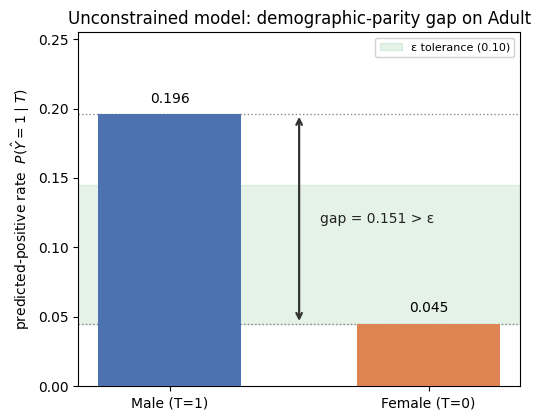

In [5]:
# Visualize the demographic-parity gap measured on the test set above: each
# group's predicted-positive rate, with the epsilon tolerance band drawn up from
# the lower rate. The constraint is violated when the other bar clears the band.
import matplotlib.pyplot as plt

eps = 0.10  # the tolerance enforced by the fairness constraint below
rates = [pr_male, pr_female]
labels = ["Male (T=1)", "Female (T=0)"]
colors = ["#4C72B0", "#DD8452"]
lo, hi = min(rates), max(rates)

fig, ax = plt.subplots(figsize=(5.4, 4.3))
ax.axhspan(
    lo,
    lo + eps,
    color="#55A868",
    alpha=0.15,
    zorder=1,
    label=f"\u03b5 tolerance ({eps:.2f})",
)
ax.axhline(lo, ls=":", color="#888888", lw=1, zorder=2)
ax.axhline(hi, ls=":", color="#888888", lw=1, zorder=2)

bars = ax.bar(labels, rates, color=colors, width=0.55, zorder=3)
for bar, rate in zip(bars, rates):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        rate + 0.006,
        f"{rate:.3f}",
        ha="center",
        va="bottom",
        fontsize=10,
    )

# gap arrow drawn in the empty space between the two bars
ax.annotate(
    "",
    xy=(0.5, hi),
    xytext=(0.5, lo),
    arrowprops=dict(arrowstyle="<->", color="#333333", lw=1.6),
)
ax.text(
    0.58,
    (lo + hi) / 2,
    f"gap = {dp_gap:.3f} > \u03b5",
    va="center",
    ha="left",
    fontsize=10,
    color="#222222",
)

ax.set_ylim(0, max(rates) * 1.3)
ax.set_ylabel(r"predicted-positive rate  $P(\hat{Y}=1 \mid T)$")
ax.set_title("Unconstrained model: demographic-parity gap on Adult", fontsize=12)
ax.legend(loc="upper right", fontsize=8, framealpha=0.9)
fig.tight_layout()
plt.show()

## 3. The Seldonian guarantee (demographic parity)

Now we ask QSA to return a model only if it can certify the demographic-parity
constraint holds with high probability. On this data it declines.

In [6]:
# Demographic parity: equal predicted-positive rate across groups.
# Within a group, P(pred = 1) = TP + FP, so the constraint (in postfix form) is
# |(TP(1) + FP(1)) - (TP(0) + FP(0))| - 0.10 <= 0.
constraint = "TP(1) FP(1) + TP(0) FP(0) + - abs 0.1 -"
config = SeldonianConfig(constraint=constraint)

_, _, passed = QSA(X_tr, Y_tr, T_tr, "opt", None, None, config)

if passed:
    print("certified: demographic parity holds with high confidence")
else:
    print("No Solution Found - QSA will not certify demographic parity here,")
    print("rather than return a model with the disparity shown above.")

No Solution Found - QSA will not certify demographic parity here,
rather than return a model with the disparity shown above.


## Takeaway

The unconstrained model is accurate but predicts high income far more often for
one group than the other. QSA trades coverage for safety: on data where it
cannot *prove* demographic parity holds, it returns no model at all - never an
unsafe one. See [`quickstart.ipynb`](quickstart.ipynb) for cases where QSA
*does* certify, and [`custom_constraint.py`](custom_constraint.py) for other
fairness definitions.

## References

**Seldonian algorithms**

- Thomas, P. S., da Silva, B. C., Barto, A. G., Giguère, S., Brun, Y., & Brunskill, E. (2019). Preventing undesirable behavior of intelligent machines. *Science*, 366(6468), 999-1004. https://doi.org/10.1126/science.aag3311

**Demographic parity and fairness criteria**

- Dwork, C., Hardt, M., Pitassi, T., Reingold, O., & Zemel, R. (2012). Fairness through awareness. *ITCS '12*, 214-226. https://arxiv.org/abs/1104.3913
- Feldman, M., Friedler, S. A., Moeller, J., Scheidegger, C., & Venkatasubramanian, S. (2015). Certifying and removing disparate impact. *KDD '15*. https://arxiv.org/abs/1412.3756
- Hardt, M., Price, E., & Srebro, N. (2016). Equality of opportunity in supervised learning. *NeurIPS 2016*. https://arxiv.org/abs/1610.02413
- Barocas, S., Hardt, M., & Narayanan, A. (2023). *Fairness and Machine Learning: Limitations and Opportunities*. MIT Press. https://fairmlbook.org

**Dataset**

- Becker, B., & Kohavi, R. (1996). *Adult* [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5XW20
- Kohavi, R. (1996). Scaling up the accuracy of naive-Bayes classifiers: a decision-tree hybrid. *KDD '96*, 202-207. https://cdn.aaai.org/KDD/1996/KDD96-033.pdf